In [1]:
import tensorflow as tf

# Check TensorFlow version
print("TensorFlow Version:", tf.__version__)

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("GPU is available.")
    for gpu in tf.config.list_physical_devices('GPU'):
        print("GPU Details:", gpu)
else:
    print("No GPU found. Please ensure your system has a GPU and the necessary drivers installed.")


TensorFlow Version: 2.10.1
GPU is available.
GPU Details: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import json
from pathlib import Path
import logging
from typing import Tuple, Dict

class ResumeDatasetLoader:
    def __init__(self, dataset_name: str = "UpdatedResumeDataSet.csv",
                 validation_split: float = 0.2):
        """
        Initialize the Resume Dataset Loader
        
        Args:
            dataset_name: Name of the dataset file
            validation_split: Fraction of data to use for validation
        """
        # Use current directory for Jupyter notebook environment
        self.data_path = Path(dataset_name)
        self.validation_split = validation_split
        self.logger = self._setup_logger()
        
    def _setup_logger(self) -> logging.Logger:
        """Configure logging for the dataset loader"""
        # Clear existing handlers to avoid duplicate logs
        logger = logging.getLogger('ResumeDatasetLoader')
        if logger.handlers:
            logger.handlers.clear()
            
        logger.setLevel(logging.INFO)
        handler = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
        handler.setFormatter(formatter)
        logger.addHandler(handler)
        return logger
    
    def verify_dataset_path(self) -> bool:
        """
        Verify that the dataset file exists at the specified path
        
        Returns:
            bool: True if file exists, False otherwise
        """
        current_dir = os.getcwd()
        self.logger.info(f"Current working directory: {current_dir}")
        self.logger.info(f"Looking for dataset at: {self.data_path.absolute()}")
        
        if not self.data_path.exists():
            self.logger.error(f"Dataset not found at {self.data_path}")
            return False
        self.logger.info(f"Dataset found at {self.data_path}")
        return True
    
    def load_dataset(self) -> pd.DataFrame:
        """
        Load the resume dataset and perform initial validation
        
        Returns:
            DataFrame containing the resume data
        """
        try:
            # First verify the path
            if not self.verify_dataset_path():
                raise FileNotFoundError(f"Dataset not found at {self.data_path}")
            
            self.logger.info(f"Loading dataset from {self.data_path}")
            df = pd.read_csv(self.data_path)
            self.logger.info(f"Successfully loaded {len(df)} resumes")
            
            # Display initial dataset information
            self.logger.info("\nDataset Overview:")
            self.logger.info(f"Shape: {df.shape}")
            self.logger.info(f"Columns: {df.columns.tolist()}")
            
            # Display first few column names for verification
            self.logger.info("\nFirst few columns:")
            for col in list(df.columns)[:5]:
                self.logger.info(f"- {col}")
            
            return df
        except Exception as e:
            self.logger.error(f"Error loading dataset: {str(e)}")
            raise
    
    def validate_data(self, df: pd.DataFrame) -> Dict[str, bool]:
        """
        Perform initial validation checks on the dataset
        
        Args:
            df: DataFrame containing resume data
            
        Returns:
            Dictionary containing validation results
        """
        validation_results = {
            'has_required_columns': False,
            'no_empty_resumes': False,
            'valid_text_format': False,
            'has_sufficient_data': False
        }
        
        # Log actual columns for debugging
        self.logger.info(f"\nActual columns in dataset: {df.columns.tolist()}")
        
        # Check required columns (adjust these based on your actual column names)
        required_columns = ['Resume', 'Category']  # Modified to match likely column names
        validation_results['has_required_columns'] = all(col in df.columns 
                                                       for col in required_columns)
        
        # Check for empty resumes
        if 'Resume' in df.columns:  # Modified column name
            validation_results['no_empty_resumes'] = df['Resume'].notna().all()
        
        # Check text format
        if 'Resume' in df.columns:  # Modified column name
            validation_results['valid_text_format'] = df['Resume'].dtype == object
            
        # Check data size
        validation_results['has_sufficient_data'] = len(df) >= 100
        
        return validation_results

    def prepare_tf_dataset(self, df: pd.DataFrame) -> Tuple[tf.data.Dataset, tf.data.Dataset]:
        """
        Convert the DataFrame into TensorFlow datasets for training and validation
        
        Args:
            df: DataFrame containing resume data
            
        Returns:
            Tuple of (training_dataset, validation_dataset)
        """
        # Shuffle the data
        df = df.sample(frac=1, random_state=42)
        
        # Split into train and validation
        split_idx = int(len(df) * (1 - self.validation_split))
        train_df = df[:split_idx]
        val_df = df[split_idx:]
        
        # Convert to TF datasets
        train_ds = tf.data.Dataset.from_tensor_slices(dict(train_df))
        val_ds = tf.data.Dataset.from_tensor_slices(dict(val_df))
        
        self.logger.info(f"Created TF datasets - Training: {len(train_df)} samples, "
                        f"Validation: {len(val_df)} samples")
        
        return train_ds, val_ds

# Test the loader
loader = ResumeDatasetLoader()

try:
    # Load dataset
    df = loader.load_dataset()
    
    # Validate data
    validation_results = loader.validate_data(df)
    print("\nValidation Results:")
    for check, result in validation_results.items():
        print(f"{check}: {'✓' if result else '✗'}")
    
    # Prepare TF datasets
    train_ds, val_ds = loader.prepare_tf_dataset(df)
    
    print("\nDataset preparation completed successfully!")
    
except Exception as e:
    print(f"Error in dataset preparation: {str(e)}")

2024-12-07 01:00:10,056 - ResumeDatasetLoader - INFO - Current working directory: C:\Users\asims\GenAI_Project
2024-12-07 01:00:10,056 - ResumeDatasetLoader - INFO - Looking for dataset at: C:\Users\asims\GenAI_Project\UpdatedResumeDataSet.csv
2024-12-07 01:00:10,056 - ResumeDatasetLoader - INFO - Dataset found at UpdatedResumeDataSet.csv
2024-12-07 01:00:10,063 - ResumeDatasetLoader - INFO - Loading dataset from UpdatedResumeDataSet.csv
2024-12-07 01:00:10,366 - ResumeDatasetLoader - INFO - Successfully loaded 962 resumes
2024-12-07 01:00:10,371 - ResumeDatasetLoader - INFO - 
Dataset Overview:
2024-12-07 01:00:10,373 - ResumeDatasetLoader - INFO - Shape: (962, 2)
2024-12-07 01:00:10,374 - ResumeDatasetLoader - INFO - Columns: ['Category', 'Resume']
2024-12-07 01:00:10,374 - ResumeDatasetLoader - INFO - 
First few columns:
2024-12-07 01:00:10,374 - ResumeDatasetLoader - INFO - - Category
2024-12-07 01:00:10,374 - ResumeDatasetLoader - INFO - - Resume
2024-12-07 01:00:10,380 - ResumeDa


Validation Results:
has_required_columns: ✓
no_empty_resumes: ✓
valid_text_format: ✓
has_sufficient_data: ✓


2024-12-07 01:00:18,387 - ResumeDatasetLoader - INFO - Created TF datasets - Training: 769 samples, Validation: 193 samples



Dataset preparation completed successfully!


In [10]:
!pip install nltk


  Using cached click-8.1.7-py3-none-any.whl.metadata (3.0 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.5 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.3 MB/s eta 0:00:00
Using cached click-8.1.7-py3-none-any.whl (97 kB)


In [12]:
!pip install spacy


  Using cached numpy-2.0.2-cp310-cp310-win_amd64.whl.metadata (59 kB)
  Using cached rich-13.9.4-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/12.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.2 MB 4.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/12.2 MB 4.9 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.2 MB 5.8 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/12.2 MB 4.9 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/12.2 MB 4.9 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.2 MB 3.5 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.2 MB 3.7 MB/s eta 0:00:03
   ------------------ --------------------- 5.8/12.2 MB 3.9 MB/s eta 0:00:02
   ------------------ --------------------- 5.8/12

  You can safely remove it manually.
  You can safely remove it manually.


In [19]:

!pip install nltk pandas numpy spacy
!python -m spacy download en_core_web_sm


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 1.9 MB/s eta 0:00:07
     --- ------------------------------------ 1.0/12.8 MB 2.8 MB/s eta 0:00:05
     ----- ---------------------------------- 1.8/12.8 MB 2.8 MB/s eta 0:00:04
     -------- ------------------------------- 2.6/12.8 MB 3.1 MB/s eta 0:00:04
     ----------- ---------------------------- 3.7/12.8 MB 3.5 MB/s eta 0:00:03
     ------------- -------------------------- 4.5/12.8 MB 3.5 MB/s eta 0:00:03
     ---------------- ----------------------- 5.2/12.8 MB 3.7 MB/s eta 0:00:03
     -------------------- ------------------- 6.6/12.8 MB 3.9 MB/s eta 0:00:02
     ---------------------- ----------------- 7.1/12.8 MB 3.9 MB/s eta 0:00:02
     ---------------------- ----------------- 7.3/12.8 MB 3.7 MB/s eta 0:00:02
     ----------------------- ---------------- 7.6/12.8 MB 3.5 MB/s

In [25]:
pip install pandas numpy nltk

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import re
from nltk.tokenize import RegexpTokenizer
import logging
from typing import Dict, List, Tuple

class ResumeDatasetLoader:
    def __init__(self, dataset_name: str = "UpdatedResumeDataSet.csv"):
        """Initialize the Resume Dataset Loader"""
        self.data_path = dataset_name
        self.logger = self._setup_logger()
        
    def _setup_logger(self) -> logging.Logger:
        """Configure logging"""
        logger = logging.getLogger('ResumeDatasetLoader')
        if logger.handlers:
            logger.handlers.clear()
        logger.setLevel(logging.INFO)
        handler = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
        handler.setFormatter(formatter)
        logger.addHandler(handler)
        return logger
        
    def load_dataset(self) -> pd.DataFrame:
        """Load the resume dataset"""
        try:
            self.logger.info(f"Current working directory: {os.getcwd()}")
            self.logger.info(f"Looking for dataset at: {os.path.abspath(self.data_path)}")
            
            if not os.path.exists(self.data_path):
                raise FileNotFoundError(f"Dataset not found at {self.data_path}")
            
            self.logger.info(f"Dataset found at {self.data_path}")
            self.logger.info(f"Loading dataset from {self.data_path}")
            df = pd.read_csv(self.data_path)
            self.logger.info(f"Successfully loaded {len(df)} resumes")
            
            self.logger.info("\nDataset Overview:")
            self.logger.info(f"Shape: {df.shape}")
            self.logger.info(f"Columns: {df.columns.tolist()}")
            
            self.logger.info("\nFirst few columns:")
            for col in df.columns:
                self.logger.info(f"- {col}")
            
            return df
            
        except Exception as e:
            self.logger.error(f"Error loading dataset: {str(e)}")
            raise

class ResumePreprocessor:
    def __init__(self):
        self.logger = self._setup_logger()
        self.word_tokenizer = RegexpTokenizer(r'\w+')
        
        # More specific section headers with multiple formats
        self.section_headers = {
            'education': [
                r'\b(?:education|academic|qualification)s?\b',
                r'\beducational (?:background|qualification)s?\b',
                r'\bacademic (?:background|qualification)s?\b',
                r'\buniversity|college|school\b',
                r'\bdegree\b'
            ],
            'experience': [
                r'\b(?:work |professional )?experience\b',
                r'\bemployment(?: history)?\b',
                r'\bwork history\b',
                r'\bcareer(?: history| summary)?\b',
                r'\bjob history\b',
                r'\bprofessional background\b'
            ],
            'skills': [
                r'\btechnical skills\b',
                r'\bskills(?: set)?\b',
                r'\bcore competencies\b',
                r'\bkey skills\b',
                r'\bproficiencies\b',
                r'\btechnical expertise\b',
                r'\bskill highlights\b'
            ],
            'projects': [
                r'\bprojects?\b',
                r'\bproject experience\b',
                r'\bkey projects\b',
                r'\bmajor projects\b',
                r'\bacademic projects\b',
                r'\bproject details\b'
            ],
            'summary': [
                r'\b(?:professional )?summary\b',
                r'\bprofile\b',
                r'\bcareer objective\b',
                r'\bobjective\b',
                r'\babout(?: me)?\b',
                r'\bintroduction\b'
            ]
        }
        
        # Enhanced skill sets with more categories
        self.technical_skills = {
            'programming_languages': {
                'python', 'java', 'javascript', 'cpp', 'c++', 'ruby', 'php', 'scala',
                'html', 'css', 'sql', 'nosql', 'rust', 'julia', 'matlab', 'r',
                'swift', 'kotlin', 'typescript', 'go', 'perl', 'shell', 'bash'
            },
            'frameworks': {
                'django', 'flask', 'spring', 'react', 'angular', 'vue', 
                'tensorflow', 'pytorch', 'keras', 'scikit', 'pandas', 'numpy',
                'scipy', 'matplotlib', 'seaborn', 'plotly', 'fastapi', 'express',
                'bootstrap', 'jquery', 'node.js', 'laravel', 'asp.net'
            },
            'databases': {
                'mysql', 'postgresql', 'mongodb', 'cassandra', 'oracle',
                'sqlite', 'redis', 'elasticsearch', 'dynamodb', 'mariadb',
                'neo4j', 'couchdb', 'hbase', 'sql server'
            },
            'tools_and_platforms': {
                'git', 'docker', 'kubernetes', 'jenkins', 'jira', 'aws',
                'azure', 'gcp', 'hadoop', 'spark', 'tableau', 'power bi',
                'linux', 'unix', 'vscode', 'intellij', 'postman', 'nginx',
                'maven', 'gradle', 'jupyter', 'airflow', 'kafka'
            },
            'machine_learning': {
                'machine learning', 'deep learning', 'nlp', 'computer vision',
                'neural networks', 'clustering', 'classification', 'regression',
                'supervised learning', 'unsupervised learning', 'reinforcement learning',
                'time series', 'natural language processing', 'ai'
            }
        }

    def _setup_logger(self) -> logging.Logger:
        logger = logging.getLogger('ResumePreprocessor')
        if logger.handlers:
            logger.handlers.clear()
        logger.setLevel(logging.INFO)
        handler = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
        handler.setFormatter(formatter)
        logger.addHandler(handler)
        return logger

    def clean_text(self, text: str) -> str:
        """Enhanced text cleaning with better section preservation"""
        if pd.isna(text):
            return ""
        
        # Normalize line endings
        text = text.replace('\r\n', '\n').replace('\r', '\n')
        
        # Mark potential section headers before cleaning
        for section, patterns in self.section_headers.items():
            for pattern in patterns:
                text = re.sub(
                    f'(^|\n)({pattern})(:|\.|\n|$)',
                    f'\n=={section.upper()}==\n',
                    text,
                    flags=re.IGNORECASE | re.MULTILINE
                )
        
        # Basic cleaning
        text = re.sub(r'\S+@\S+', 'EMAIL', text)
        text = re.sub(r'\(?\d{3}\)?[-.]?\d{3}[-.]?\d{4}', 'PHONE', text)
        text = re.sub(r'http\S+|www.\S+', 'URL', text)
        
        # Remove extra whitespace while preserving section markers
        lines = [line.strip() for line in text.split('\n')]
        text = '\n'.join(line for line in lines if line)
        
        return text

    def identify_sections(self, text: str) -> Dict[str, str]:
        """Improved section identification with better boundary detection"""
        sections = {k: '' for k in self.section_headers.keys()}
        
        # Split into chunks by section markers
        chunks = re.split(r'==(\w+)==', text)
        
        if len(chunks) > 1:  # Found section markers
            current_section = None
            for chunk in chunks:
                chunk = chunk.strip()
                if chunk in sections.keys():
                    current_section = chunk.lower()
                elif current_section and chunk:
                    sections[current_section] += chunk + '\n'
        else:
            # Fallback: try to identify sections without markers
            lines = text.split('\n')
            current_section = None
            buffer = []
            
            for line in lines:
                line = line.strip()
                if not line:
                    continue
                
                # Check if this line matches any section header
                found_section = None
                for section, patterns in self.section_headers.items():
                    if any(re.search(pattern, line, re.IGNORECASE) for pattern in patterns):
                        found_section = section
                        break
                
                if found_section:
                    # Save previous section
                    if current_section and buffer:
                        sections[current_section] = '\n'.join(buffer)
                    current_section = found_section
                    buffer = []
                elif current_section:
                    buffer.append(line)
            
            # Save last section
            if current_section and buffer:
                sections[current_section] = '\n'.join(buffer)
        
        return sections

    def _clean_section_content(self, content: str) -> str:
        """Clean section content while preserving important formatting"""
        lines = []
        for line in content.split('\n'):
            line = line.strip()
            if line and not any(indicator.lower() in line.lower() 
                              for indicators in self.section_indicators.values() 
                              for indicator in indicators):
                lines.append(line)
        
        return '\n'.join(lines)

    def extract_skills(self, text: str) -> Dict[str, List[str]]:
        """Enhanced skill extraction with improved pattern matching"""
        text_lower = text.lower()
        found_skills = {}
        
        for category, skills in self.technical_skills.items():
            # Initialize empty set for this category
            found = set()
            
            # Single word skills
            words = set(self.word_tokenizer.tokenize(text_lower))
            found.update(skill for skill in skills if skill in words)
            
            # Multi-word skills
            for skill in skills:
                if ' ' in skill and skill in text_lower:
                    found.add(skill)
                # Handle variations (e.g., "machine-learning" vs "machine learning")
                elif '-' in skill and skill.replace('-', ' ') in text_lower:
                    found.add(skill)
            
            found_skills[category] = sorted(found)
        
        return found_skills

    def process_dataframe(self, df: pd.DataFrame) -> pd.DataFrame:
        """Process entire dataframe with improved structure"""
        self.logger.info("Starting resume preprocessing...")
        
        processed_data = []
        for idx, row in df.iterrows():
            if idx % 100 == 0:
                self.logger.info(f"Processing resume {idx}")
            
            cleaned_text = self.clean_text(row['Resume'])
            sections = self.identify_sections(cleaned_text)
            skills = self.extract_skills(cleaned_text)
            
            processed_data.append({
                'category': row['Category'],
                'sections': sections,
                'skills': skills,
                'original_text': row['Resume'],
                'cleaned_text': cleaned_text
            })
        
        self.logger.info("Resume preprocessing completed!")
        return pd.DataFrame(processed_data)

def display_resume_analysis(resume_data: pd.Series):
    """Enhanced display of processed resume information"""
    print(f"\nCategory: {resume_data['category']}\n")
    
    print("Identified Sections:")
    for section, content in resume_data['sections'].items():
        if content.strip():
            print(f"\n{section.upper()}:")
            print("-" * 50)
            content_preview = content[:300]
            if len(content) > 300:
                content_preview += "..."
            print(content_preview)
            print("-" * 50)
    
    print("\nExtracted Skills:")
    for category, skills in resume_data['skills'].items():
        if skills:
            print(f"\n{category.replace('_', ' ').title()}:")
            print(", ".join(skills))

def print_statistics(processed_df: pd.DataFrame, preprocessor: ResumePreprocessor):
    """Print detailed statistics about the processed resumes"""
    print("\nDataset Statistics:")
    print(f"Total Resumes Processed: {len(processed_df)}")
    
    print("\nSection Detection Stats:")
    for section in preprocessor.section_headers.keys():
        has_section = sum(processed_df['sections'].apply(lambda x: bool(x[section].strip())))
        print(f"{section.title()}: {has_section} resumes ({has_section/len(processed_df)*100:.1f}%)")
    
    print("\nSkill Distribution:")
    for category in preprocessor.technical_skills.keys():
        skills_count = processed_df['skills'].apply(lambda x: len(x[category])).mean()
        max_skills = processed_df['skills'].apply(lambda x: len(x[category])).max()
        print(f"{category.replace('_', ' ').title()}:")
        print(f"  - Average: {skills_count:.1f} skills per resume")
        print(f"  - Maximum: {max_skills} skills in a single resume")

def main():
    # Load dataset
    loader = ResumeDatasetLoader()
    df = loader.load_dataset()
    
    # Process resumes
    preprocessor = ResumePreprocessor()
    processed_df = preprocessor.process_dataframe(df)
    
    # Display sample results
    print("\nSample Resume Analysis:")
    display_resume_analysis(processed_df.iloc[0])
    
    # Print detailed statistics
    print_statistics(processed_df, preprocessor)

if __name__ == "__main__":
    main()

2024-12-07 01:00:43,637 - ResumeDatasetLoader - INFO - Current working directory: C:\Users\asims\GenAI_Project
2024-12-07 01:00:43,637 - ResumeDatasetLoader - INFO - Looking for dataset at: C:\Users\asims\GenAI_Project\UpdatedResumeDataSet.csv
2024-12-07 01:00:43,643 - ResumeDatasetLoader - INFO - Dataset found at UpdatedResumeDataSet.csv
2024-12-07 01:00:43,646 - ResumeDatasetLoader - INFO - Loading dataset from UpdatedResumeDataSet.csv
2024-12-07 01:00:43,696 - ResumeDatasetLoader - INFO - Successfully loaded 962 resumes
2024-12-07 01:00:43,702 - ResumeDatasetLoader - INFO - 
Dataset Overview:
2024-12-07 01:00:43,705 - ResumeDatasetLoader - INFO - Shape: (962, 2)
2024-12-07 01:00:43,705 - ResumeDatasetLoader - INFO - Columns: ['Category', 'Resume']
2024-12-07 01:00:43,705 - ResumeDatasetLoader - INFO - 
First few columns:
2024-12-07 01:00:43,710 - ResumeDatasetLoader - INFO - - Category
2024-12-07 01:00:43,710 - ResumeDatasetLoader - INFO - - Resume
2024-12-07 01:00:43,713 - ResumePr


Sample Resume Analysis:

Category: Data Science

Identified Sections:

EDUCATION:
--------------------------------------------------
Data Science Assurance Associate
Data Science Assurance Associate - Ernst & Young LLP
Skill Details
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details
company - Ernst & Young LLP
description - Fraud Investigations and Dispute Services   Assur...
--------------------------------------------------

PROJECTS:
--------------------------------------------------
TEXT ANALYTICS - MOTOR VEHICLE CUSTOMER REVIEW DATA * Received customer feedback survey data for past one year. Performed sentiment (Positive, Negative & Neutral) and time series analysis on customer comments across all 4 categories.
* Created heat map of terms by survey category based on frequency ...
--------------------------------------------------

SUMMARY:
--------------------------------------------------
* Scan data from multiple sources

1. Category Distribution
--------------------------------------------------


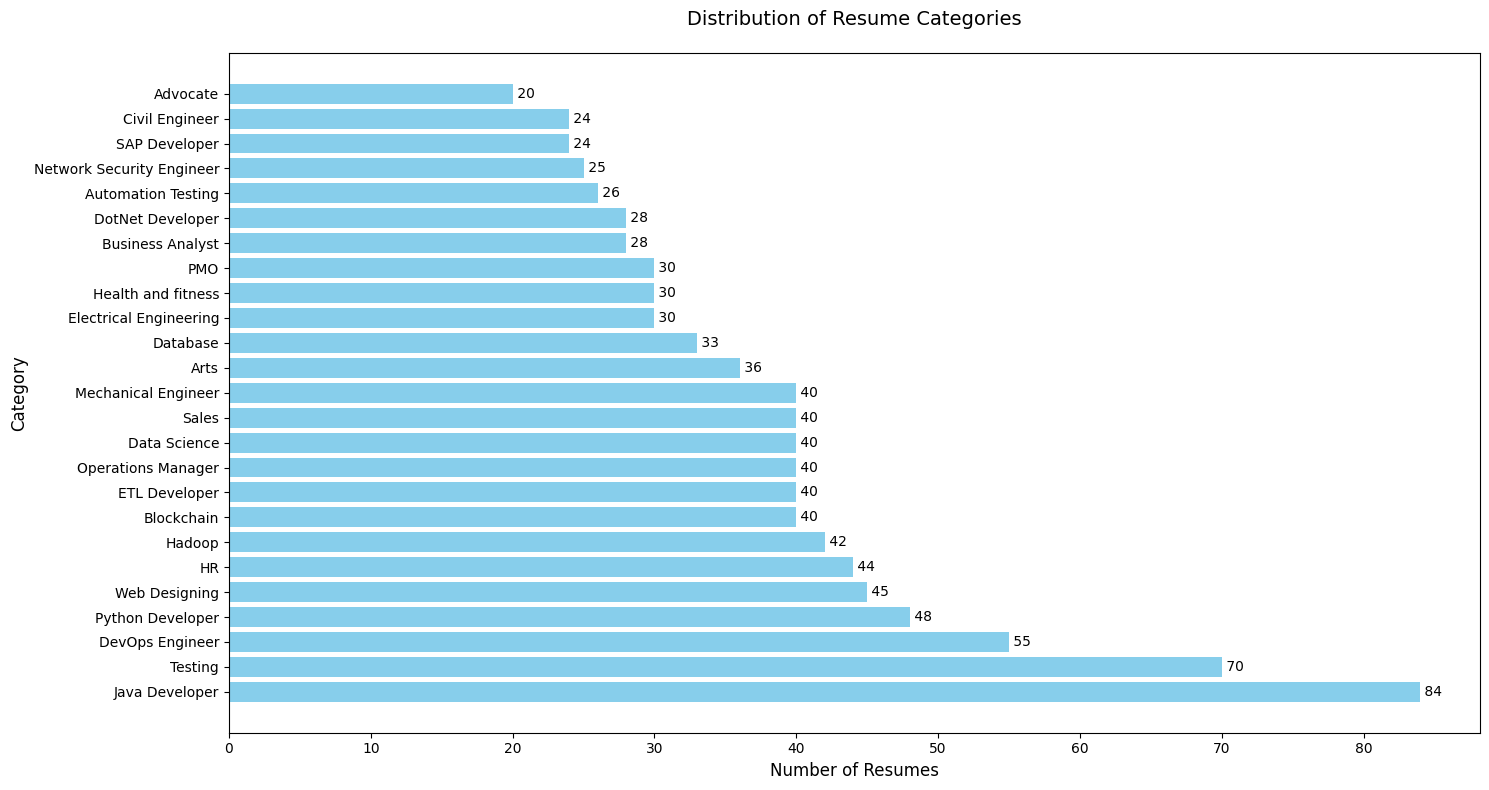


Category Distribution Statistics:
------------------------------
Java Developer: 84 (8.7%)
Testing: 70 (7.3%)
DevOps Engineer: 55 (5.7%)
Python Developer: 48 (5.0%)
Web Designing: 45 (4.7%)
HR: 44 (4.6%)
Hadoop: 42 (4.4%)
Blockchain: 40 (4.2%)
ETL Developer: 40 (4.2%)
Operations Manager: 40 (4.2%)
Data Science: 40 (4.2%)
Sales: 40 (4.2%)
Mechanical Engineer: 40 (4.2%)
Arts: 36 (3.7%)
Database: 33 (3.4%)
Electrical Engineering: 30 (3.1%)
Health and fitness: 30 (3.1%)
PMO: 30 (3.1%)
Business Analyst: 28 (2.9%)
DotNet Developer: 28 (2.9%)
Automation Testing: 26 (2.7%)
Network Security Engineer: 25 (2.6%)
SAP Developer: 24 (2.5%)
Civil Engineer: 24 (2.5%)
Advocate: 20 (2.1%)

2. Overall Skills Distribution
--------------------------------------------------


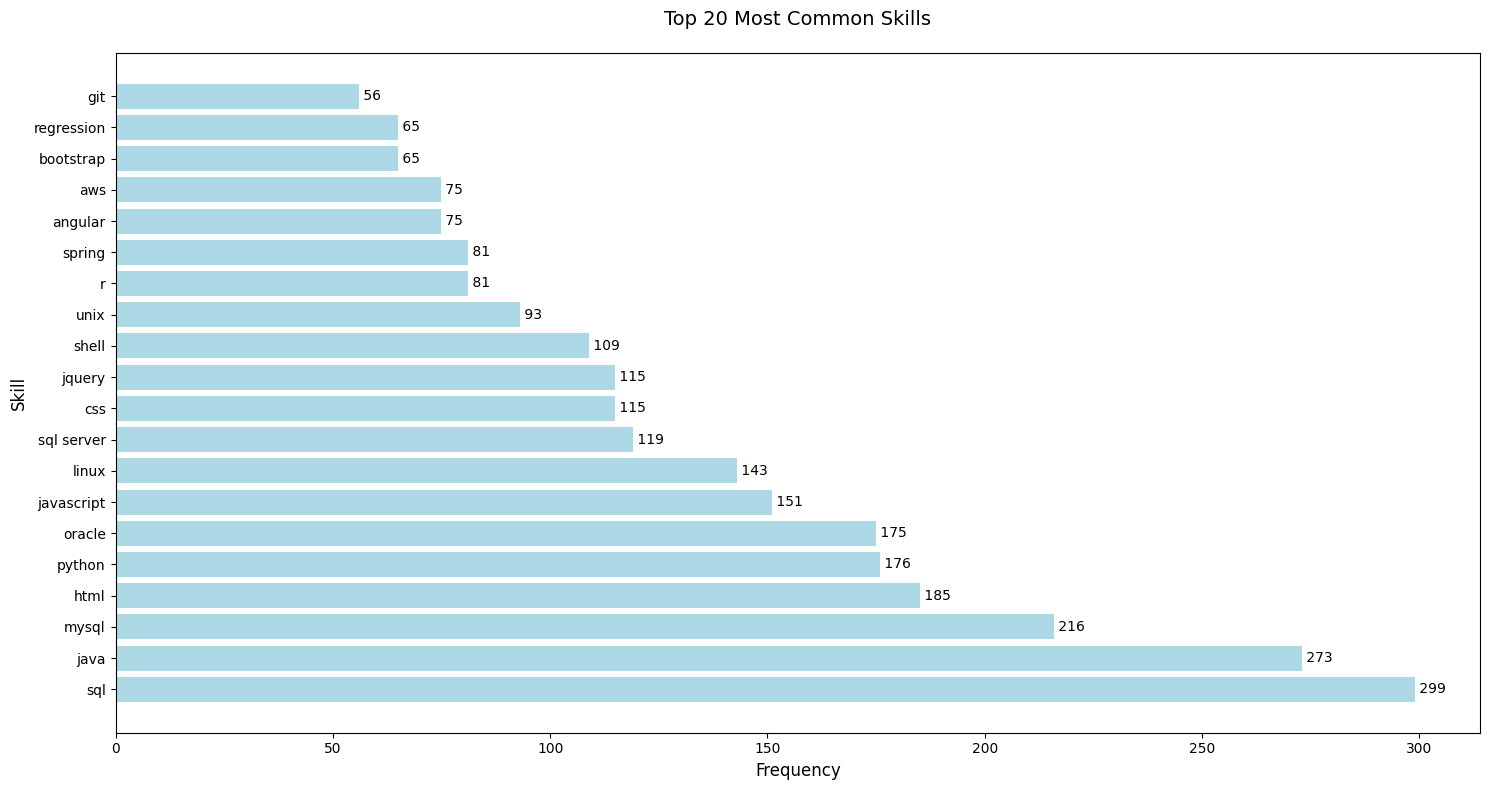


3. Skills Analysis for Java Developer
--------------------------------------------------


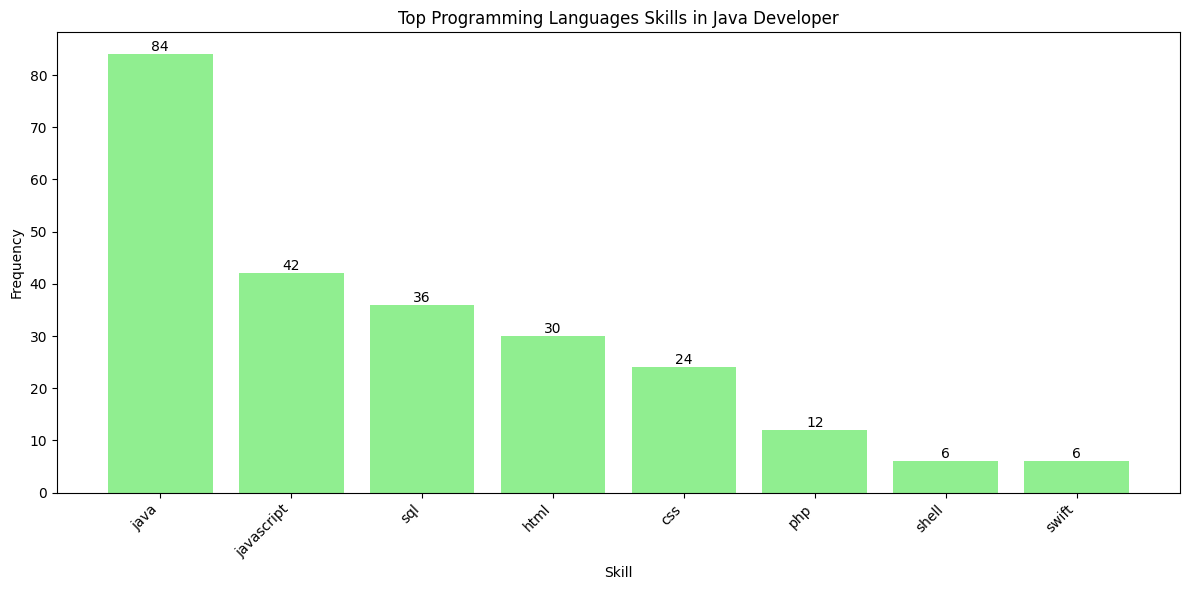

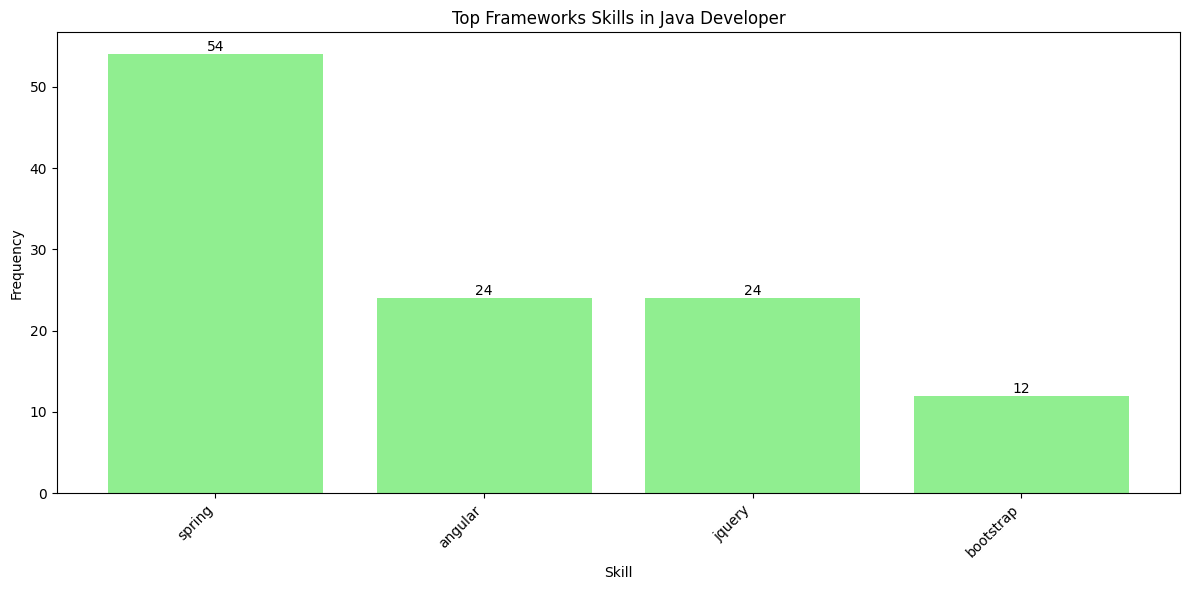

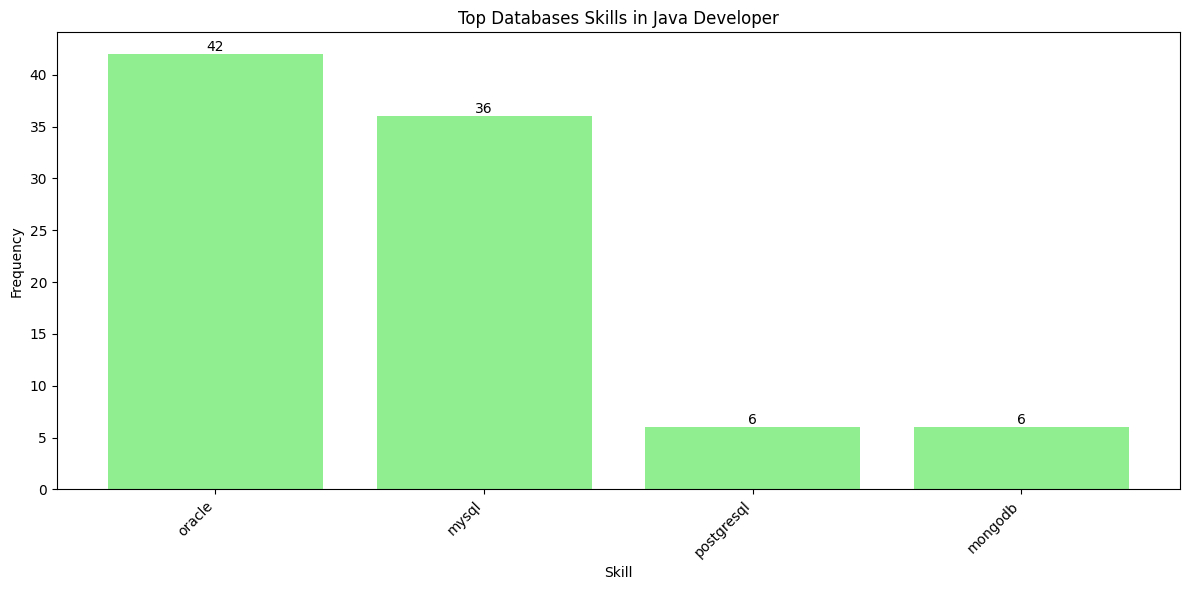

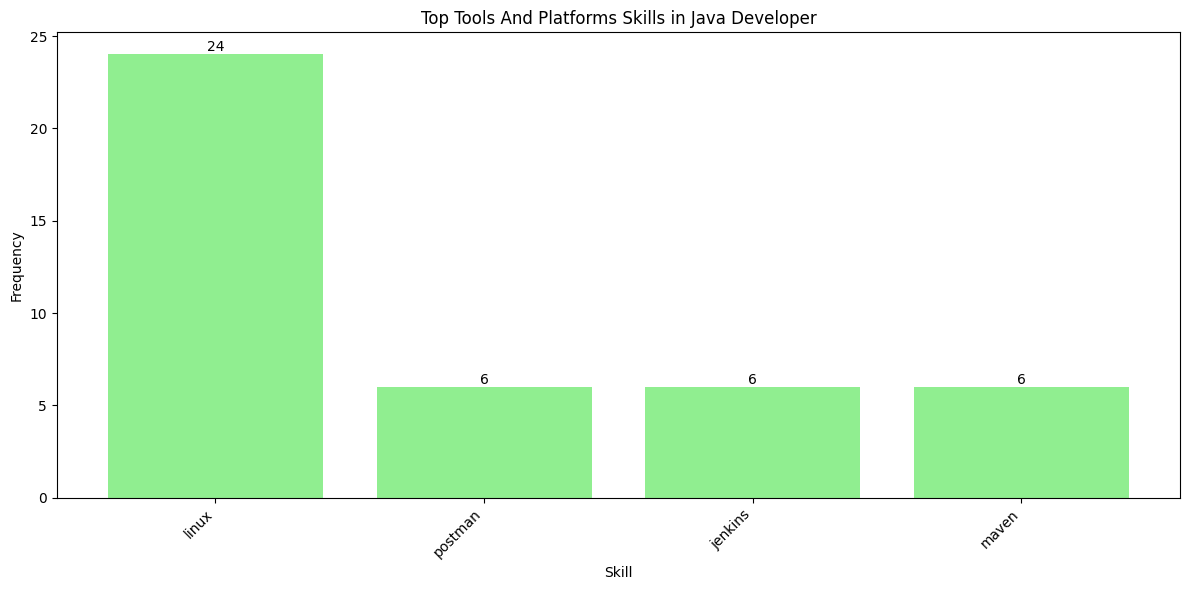


3. Skills Analysis for Testing
--------------------------------------------------


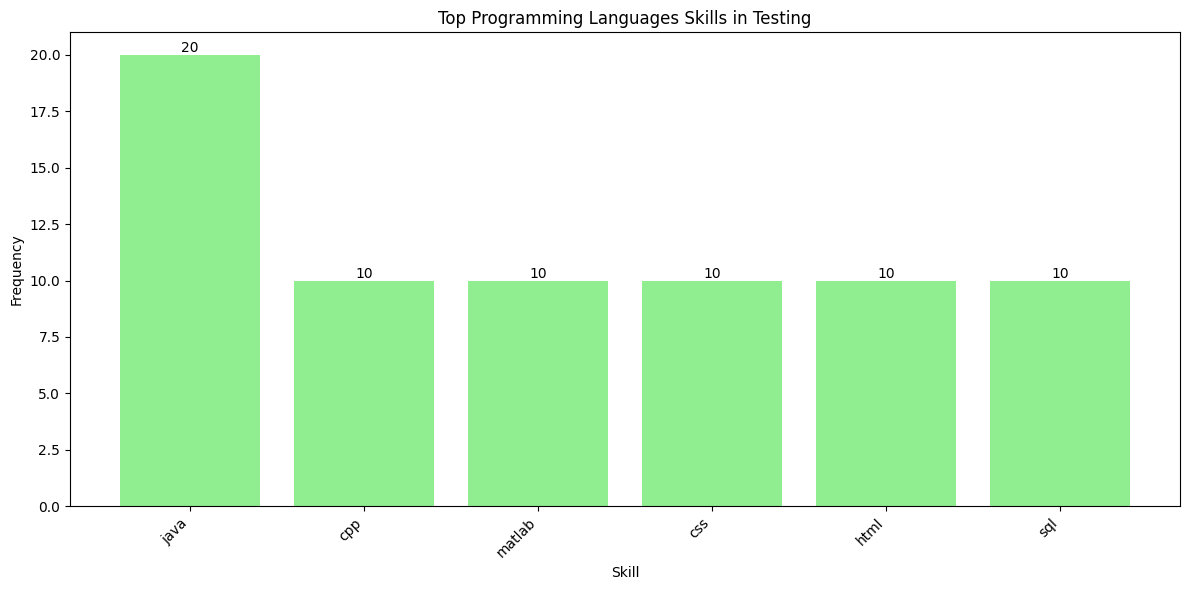

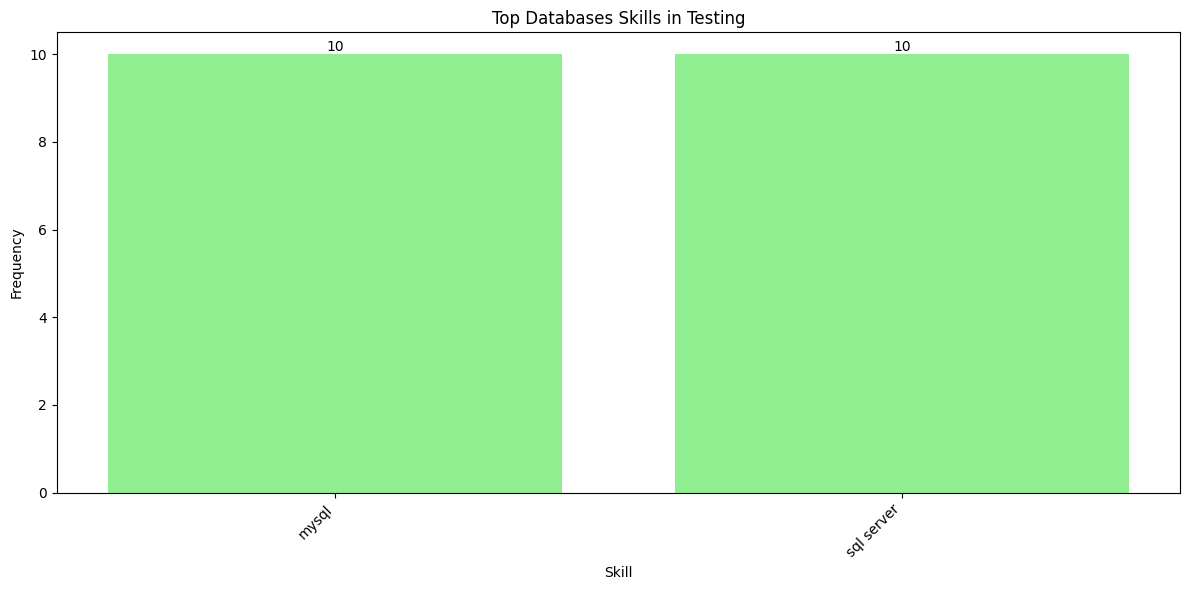

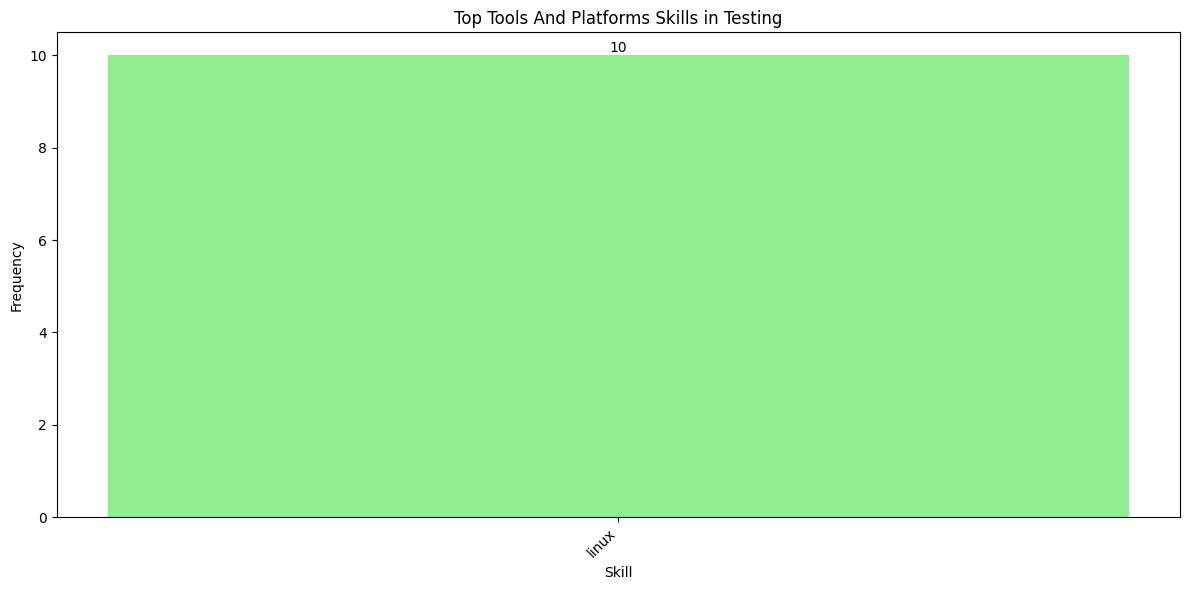

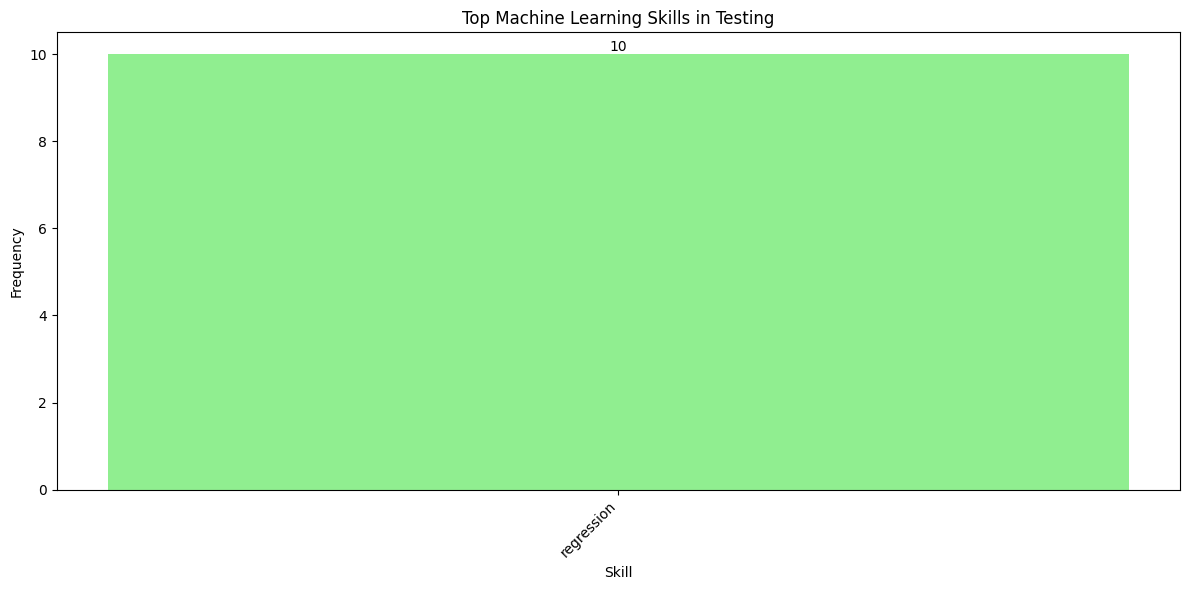


3. Skills Analysis for DevOps Engineer
--------------------------------------------------


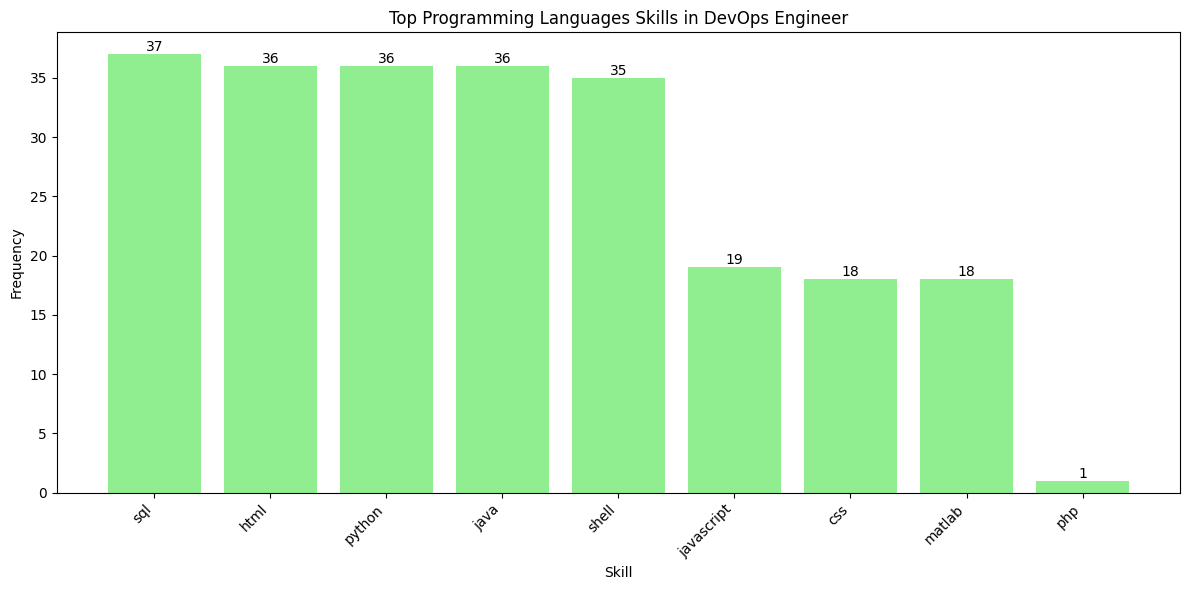

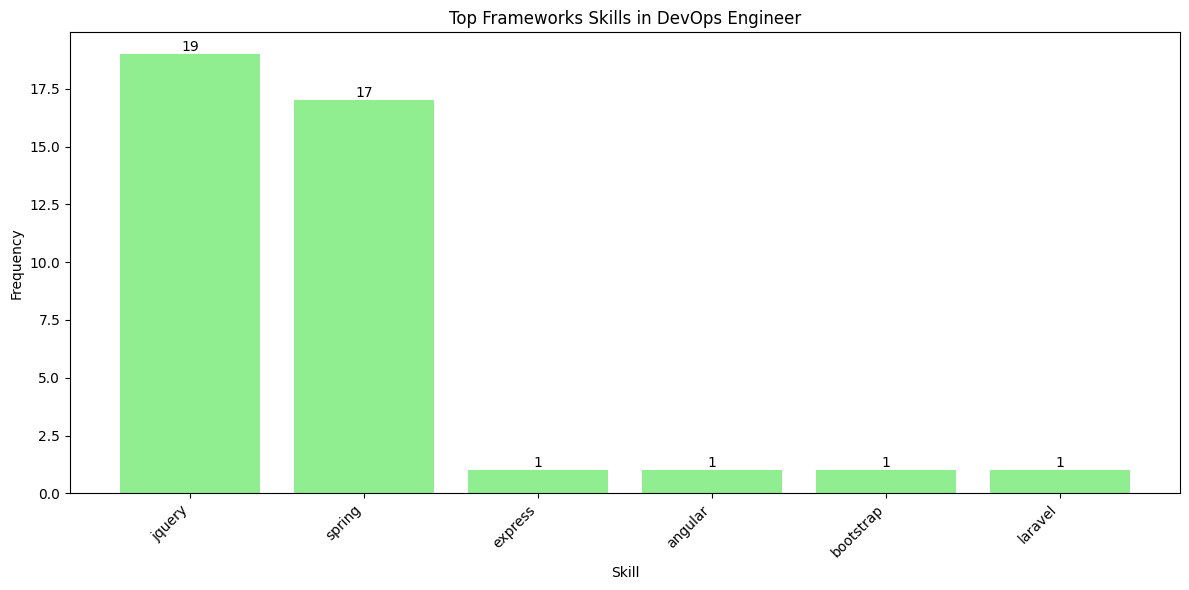

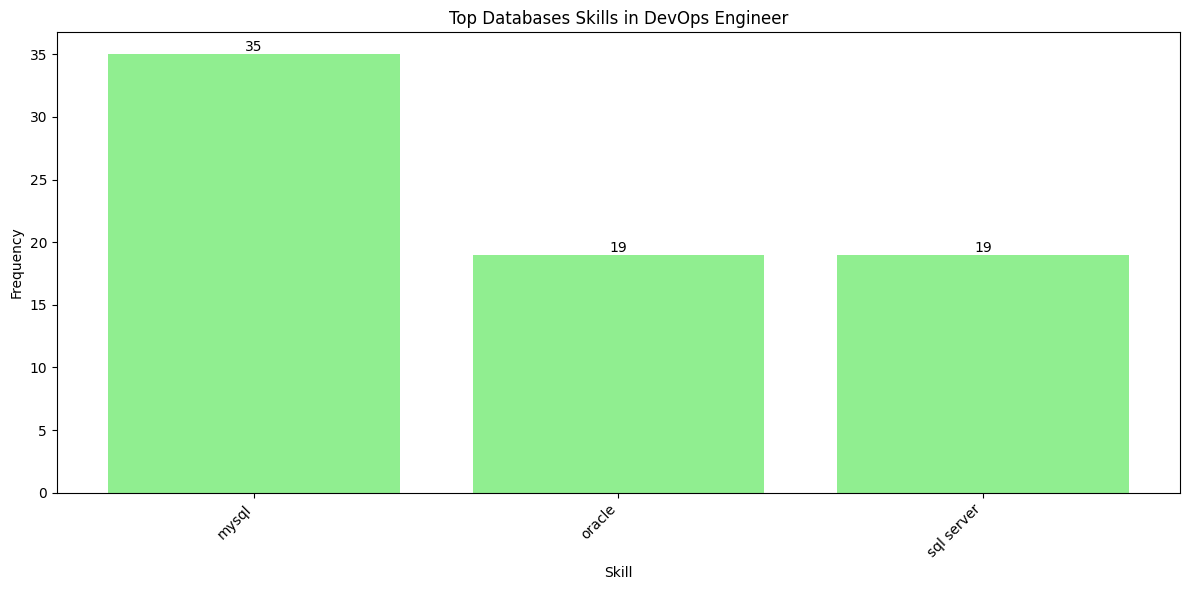

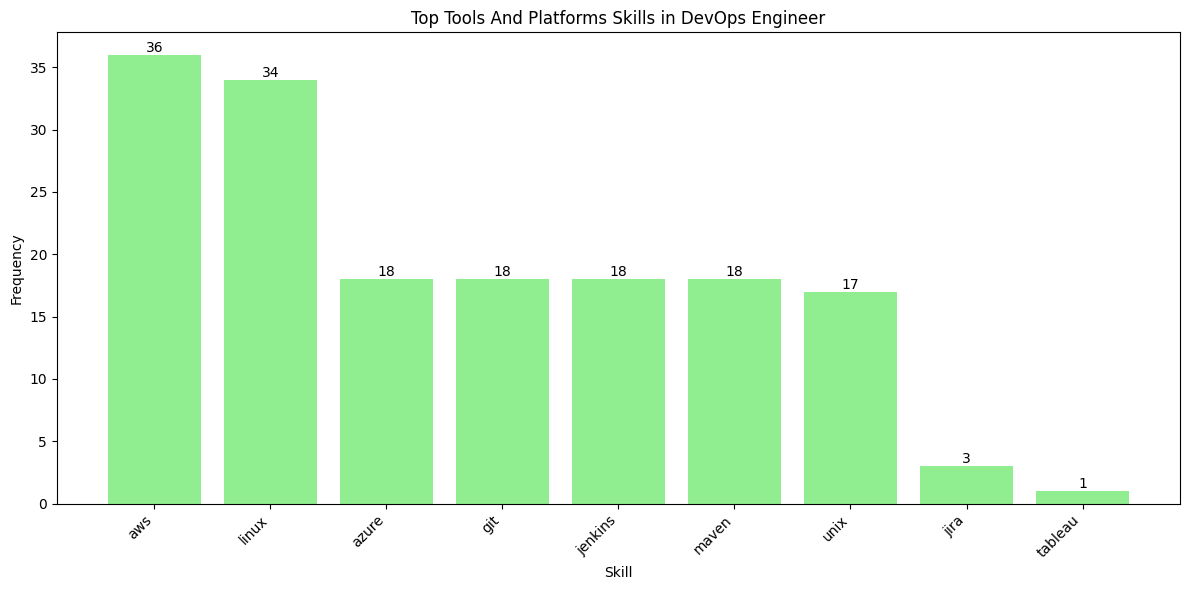

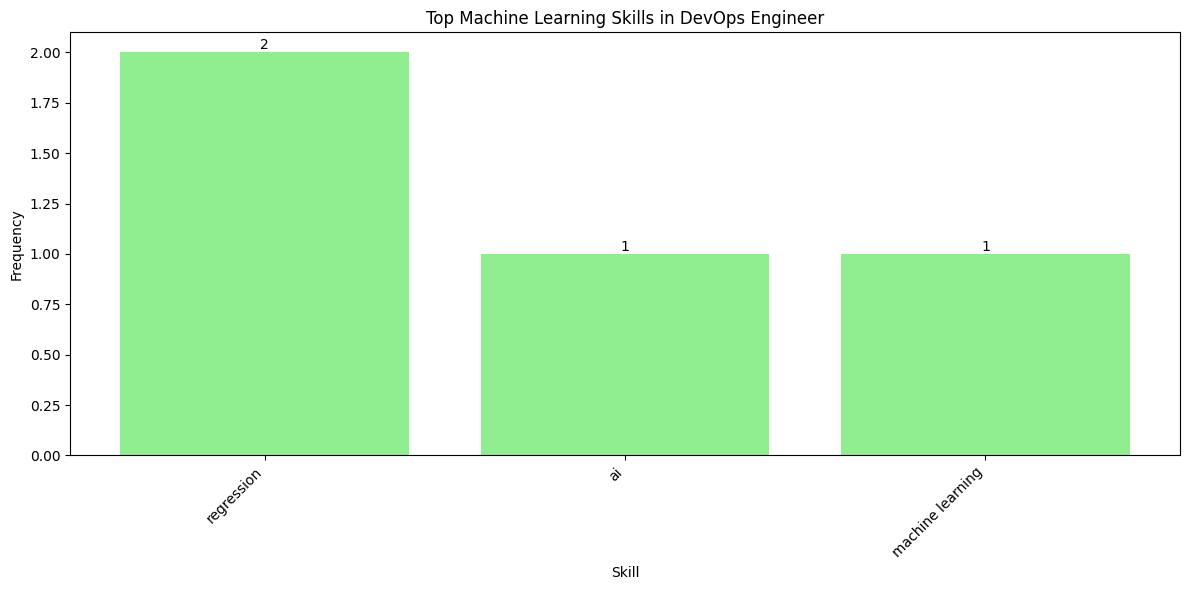

In [26]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
%matplotlib inline

# Use default style settings
plt.style.use('default')

class ResumeVisualizer:
    def __init__(self, processed_df):
        self.df = processed_df
        # Set default figure size and font sizes
        plt.rcParams['figure.figsize'] = [12, 6]
        plt.rcParams['font.size'] = 10
        
    def plot_category_distribution(self):
        """Plot distribution of resume categories"""
        # Get category counts
        category_counts = self.df['category'].value_counts()
        
        # Create figure
        plt.figure(figsize=(15, 8))
        
        # Create bar plot
        bars = plt.barh(range(len(category_counts)), category_counts.values, color='skyblue')
        
        # Customize plot
        plt.title('Distribution of Resume Categories', fontsize=14, pad=20)
        plt.xlabel('Number of Resumes', fontsize=12)
        plt.ylabel('Category', fontsize=12)
        
        # Set category labels
        plt.yticks(range(len(category_counts)), category_counts.index)
        
        # Add value labels
        for i, bar in enumerate(bars):
            width = bar.get_width()
            plt.text(width, i, f' {int(width)}', va='center')
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print("\nCategory Distribution Statistics:")
        print("-" * 30)
        total = len(self.df)
        for category, count in category_counts.items():
            print(f"{category}: {count} ({(count/total)*100:.1f}%)")
            
    def plot_skills_distribution(self):
        """Plot skills distribution across all resumes"""
        # Collect all skills
        all_skills = Counter()
        for _, row in self.df.iterrows():
            for skill_type, skills in row['skills'].items():
                all_skills.update(skills)
                
        # Get top 20 skills
        top_skills = dict(all_skills.most_common(20))
        
        # Create plot
        plt.figure(figsize=(15, 8))
        bars = plt.barh(range(len(top_skills)), list(top_skills.values()), color='lightblue')
        
        plt.title('Top 20 Most Common Skills', fontsize=14, pad=20)
        plt.xlabel('Frequency', fontsize=12)
        plt.ylabel('Skill', fontsize=12)
        
        # Set skill labels
        plt.yticks(range(len(top_skills)), list(top_skills.keys()))
        
        # Add value labels
        for i, bar in enumerate(bars):
            width = bar.get_width()
            plt.text(width, i, f' {int(width)}', va='center')
            
        plt.tight_layout()
        plt.show()
        
    def plot_skills_by_category(self, category):
        """Plot skills distribution for a specific category"""
        # Filter data for category
        category_df = self.df[self.df['category'] == category]
        
        # Collect skills
        skill_counts = {}
        for _, row in category_df.iterrows():
            for skill_type, skills in row['skills'].items():
                if skill_type not in skill_counts:
                    skill_counts[skill_type] = Counter()
                skill_counts[skill_type].update(skills)
                
        # Plot for each skill type
        for skill_type, counts in skill_counts.items():
            if counts:
                # Get top 10 skills
                top_skills = dict(counts.most_common(10))
                
                plt.figure(figsize=(12, 6))
                bars = plt.bar(range(len(top_skills)), list(top_skills.values()), color='lightgreen')
                
                plt.title(f'Top {skill_type.replace("_", " ").title()} Skills in {category}')
                plt.xticks(range(len(top_skills)), list(top_skills.keys()), rotation=45, ha='right')
                plt.xlabel('Skill')
                plt.ylabel('Frequency')
                
                # Add value labels
                for bar in bars:
                    height = bar.get_height()
                    plt.text(bar.get_x() + bar.get_width()/2., height,
                            f'{int(height)}', ha='center', va='bottom')
                
                plt.tight_layout()
                plt.show()

# Function to run the analysis
def analyze_resume_data(processed_df):
    visualizer = ResumeVisualizer(processed_df)
    
    print("1. Category Distribution")
    print("-" * 50)
    visualizer.plot_category_distribution()
    
    print("\n2. Overall Skills Distribution")
    print("-" * 50)
    visualizer.plot_skills_distribution()
    
    # Plot skills for top categories
    top_categories = processed_df['category'].value_counts().head(3).index
    for category in top_categories:
        print(f"\n3. Skills Analysis for {category}")
        print("-" * 50)
        visualizer.plot_skills_by_category(category)

# Run the analysis with your processed DataFrame
analyze_resume_data(processed_df)

In [30]:
!pip install sentence-transformers


   ---------------------------------------- 0.0/203.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/203.1 MB 3.7 MB/s eta 0:00:55
   ---------------------------------------- 2.1/203.1 MB 5.3 MB/s eta 0:00:38
    --------------------------------------- 2.9/203.1 MB 4.9 MB/s eta 0:00:41
    --------------------------------------- 3.4/203.1 MB 4.8 MB/s eta 0:00:42
    --------------------------------------- 3.4/203.1 MB 4.8 MB/s eta 0:00:42
    --------------------------------------- 4.2/203.1 MB 3.4 MB/s eta 0:00:59
   - -------------------------------------- 5.2/203.1 MB 3.7 MB/s eta 0:00:55
   - -------------------------------------- 5.5/203.1 MB 3.4 MB/s eta 0:00:58
   - -------------------------------------- 6.3/203.1 MB 3.4 MB/s eta 0:00:59
   - -------------------------------------- 6.8/203.1 MB 3.3 MB/s eta 0:01:00
   - -------------------------------------- 7.3/203.1 MB 3.2 MB/s eta 0:01:01
   - -------------------------------------- 7.6/203.1 MB 3.1 MB/s eta 0

In [33]:
!pip install faiss-cpu


   ---------------------------------------- 0.0/13.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.8 MB ? eta -:--:--
    --------------------------------------- 0.3/13.8 MB ? eta -:--:--
   --- ------------------------------------ 1.0/13.8 MB 2.7 MB/s eta 0:00:05
   ------- -------------------------------- 2.6/13.8 MB 4.3 MB/s eta 0:00:03
   -------- ------------------------------- 2.9/13.8 MB 4.2 MB/s eta 0:00:03
   -------- ------------------------------- 2.9/13.8 MB 4.2 MB/s eta 0:00:03
   ----------- ---------------------------- 3.9/13.8 MB 3.5 MB/s eta 0:00:03
   ------------ --------------------------- 4.2/13.8 MB 3.1 MB/s eta 0:00:04
   ---------------- ----------------------- 5.8/13.8 MB 3.5 MB/s eta 0:00:03
   ----------------- ---------------------- 6.0/13.8 MB 3.3 MB/s eta 0:00:03
   ------------------ --------------------- 6.6/13.8 MB 3.4 MB/s eta 0:00:03
   -------------------- ---

In [66]:
!pip install numpy==1.24.3
!pip install --upgrade "transformers>=4.41.0" sentence-transformers accelerate

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blis 1.0.1 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.24.3 which is incompatible.
faiss-cpu 1.9.0.post1 requires numpy<3.0,>=1.25.0, but you have numpy 1.24.3 which is incompatible.
thinc 8.3.2 requires numpy<2.1.0,>=2.0.0; python_version >= "3.9", but you have numpy 1.24.3 which is incompatible.



   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
   -- ------------------------------------- 1.0/14.8 MB 2.6 MB/s eta 0:00:06
   ------ --------------------------------- 2.4/14.8 MB 3.8 MB/s eta 0:00:04
   -------- ------------------------------- 3.1/14.8 MB 3.8 MB/s eta 0:00:04
   --------- ------------------------------ 3.7/14.8 MB 4.0 MB/s eta 0:00:03
   ---------- ----------------------------- 3.9/14.8 MB 3.6 MB/s eta 0:00:04
   --------------- ------------------------ 5.8/14.8 MB 4.0 MB/s eta 0:00:03
   --------------- ------------------------ 5.8/14.8 MB 4.0 MB/s eta 0:00:03
   ---------------- ----------------------- 6.0/14.8 MB 3.2 MB/s eta 0:00:03
   ------------------ --------------------- 6.8/14.8 MB 3.3 MB/s eta 0:00:03
   ------------------ ----

In [10]:
import numpy as np
import faiss
import torch
import logging
import json
import pickle
import os
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Tuple, Any, Optional
from dataclasses import dataclass
from sentence_transformers import SentenceTransformer

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

@dataclass
class EmbeddingConfig:
    """Configuration for the embedding system"""
    model_name: str = 'all-MiniLM-L6-v2'
    max_seq_length: int = 512
    batch_size: int = 32
    normalize_embeddings: bool = True
    embedding_dim: int = 384  # Dimension for all-MiniLM-L6-v2

class EmbeddingSystem:
    """Handles the creation and management of embeddings"""
    
    def __init__(self, config: EmbeddingConfig = EmbeddingConfig()):
        self.config = config
        self.model = SentenceTransformer(config.model_name)
        self.model.max_seq_length = config.max_seq_length
        logger.info(f"Initialized embedding model: {config.model_name}")

    def create_embeddings(self, texts: List[str]) -> np.ndarray:
        """Create embeddings in batches"""
        return self.model.encode(
            texts,
            batch_size=self.config.batch_size,
            normalize_embeddings=self.config.normalize_embeddings,
            show_progress_bar=True
        )

    def create_resume_embedding(self, text: str) -> np.ndarray:
        """Create embedding for complete resume"""
        return self.model.encode(
            text,
            normalize_embeddings=self.config.normalize_embeddings
        )

    def create_section_embeddings(self, sections: Dict[str, str]) -> Dict[str, np.ndarray]:
        """Create embeddings for each resume section"""
        embeddings = {}
        for section_name, content in sections.items():
            if content.strip():
                embeddings[section_name] = self.create_resume_embedding(content)
        return embeddings

    def create_skill_embeddings(self, skills: Dict[str, List[str]]) -> Dict[str, np.ndarray]:
        """Create embeddings for skill sets"""
        embeddings = {}
        for category, skill_list in skills.items():
            if skill_list:
                text = ", ".join(skill_list)
                embeddings[category] = self.create_resume_embedding(text)
        return embeddings

class VectorDatabase:
    """Manages vector storage and retrieval"""
    
    def __init__(self, dimension: int):
        self.dimension = dimension
        # Using IVFFlat index for better search performance
        self.quantizer = faiss.IndexFlatL2(dimension)
        self.index = faiss.IndexIVFFlat(self.quantizer, dimension, 100)  # 100 centroids
        self.index.train(np.zeros((1000, dimension), dtype=np.float32))  # Initial training
        self.stored_vectors: List[np.ndarray] = []
        self.metadata: List[Dict] = []
        logger.info(f"Initialized vector database with dimension {dimension}")

    def add_vectors(self, vectors: np.ndarray, metadata: List[Dict]):
        """Add vectors to the database"""
        if vectors.ndim == 1:
            vectors = vectors.reshape(1, -1)
        
        self.index.add(vectors)
        self.stored_vectors.extend(vectors)
        self.metadata.extend(metadata)
        logger.info(f"Added {len(vectors)} vectors to database")

    def search(self, query_vector: np.ndarray, k: int = 5) -> List[Tuple[int, float]]:
        """Search for similar vectors"""
        if query_vector.ndim == 1:
            query_vector = query_vector.reshape(1, -1)
        
        # Search with IVF index
        self.index.nprobe = 10  # Number of centroids to visit during search
        distances, indices = self.index.search(query_vector, k)
        return list(zip(indices[0], distances[0]))

class RAGSystem:
    """Manages the Retrieval-Augmented Generation system"""
    
    def __init__(self, embedding_system: EmbeddingSystem, vector_db: VectorDatabase):
        self.embedding_system = embedding_system
        self.vector_db = vector_db
        logger.info("Initialized RAG system")

    def process_query(self, query: str, top_k: int = 5) -> List[Dict[str, Any]]:
        """Process a query and return relevant results"""
        query_embedding = self.embedding_system.create_resume_embedding(query)
        search_results = self.vector_db.search(query_embedding, k=top_k)
        
        results = []
        for idx, score in search_results:
            if idx != -1:  # Valid index
                metadata = self.vector_db.metadata[idx]
                result = {
                    'content': metadata.get('content', ''),
                    'score': float(score),
                    'section': metadata.get('section', ''),
                    'metadata': metadata,
                    'embedding_similarity': 1 / (1 + score)  # Convert distance to similarity
                }
                results.append(result)
        
        return results

    def validate_response(self, response: str, context: List[Dict[str, Any]]) -> Tuple[bool, float]:
        """Validate response against retrieved context"""
        if not response or not context:
            return False, 0.0
            
        # Create embeddings for response and context
        response_embedding = self.embedding_system.create_resume_embedding(response)
        context_text = " ".join([ctx['content'] for ctx in context])
        context_embedding = self.embedding_system.create_resume_embedding(context_text)
        
        # Calculate cosine similarity
        similarity = np.dot(response_embedding, context_embedding) / (
            np.linalg.norm(response_embedding) * np.linalg.norm(context_embedding)
        )
        
        # Threshold for validation
        is_valid = similarity > 0.7
        return is_valid, float(similarity)

class ModelManager:
    """Handles model persistence and checkpointing"""
    
    def __init__(self, base_dir: str = "resume_analysis_model"):
        self.base_dir = Path(base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)
        self.checkpoints_dir = self.base_dir / "checkpoints"
        self.checkpoints_dir.mkdir(exist_ok=True)
        
    def save_checkpoint(self, system: 'ResumeAnalysisSystem', name: Optional[str] = None) -> str:
        """Save system checkpoint"""
        if name is None:
            name = f"checkpoint_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
            
        checkpoint_dir = self.checkpoints_dir / name
        checkpoint_dir.mkdir(exist_ok=True)
        
        # Save embedding model
        model_dir = checkpoint_dir / "embedding_model"
        system.embedding_system.model.save(str(model_dir))
        
        # Save vector database
        with open(checkpoint_dir / "vector_db.pkl", 'wb') as f:
            pickle.dump({
                'dimension': system.vector_db.dimension,
                'stored_vectors': system.vector_db.stored_vectors,
                'metadata': system.vector_db.metadata
            }, f)
        
        faiss.write_index(system.vector_db.index, str(checkpoint_dir / "faiss_index.bin"))
        
        # Save config
        config = {
            'embedding_config': vars(system.embedding_config),
            'checkpoint_name': name,
            'timestamp': datetime.now().isoformat()
        }
        
        with open(checkpoint_dir / "config.json", 'w') as f:
            json.dump(config, f, indent=4)
            
        logger.info(f"Saved checkpoint: {name}")
        return name

    def load_checkpoint(self, name: str) -> 'ResumeAnalysisSystem':
        """Load system from checkpoint"""
        checkpoint_dir = self.checkpoints_dir / name
        
        if not checkpoint_dir.exists():
            raise ValueError(f"Checkpoint {name} not found")
        
        # Load configuration
        with open(checkpoint_dir / "config.json", 'r') as f:
            config = json.load(f)
            
        # Create new system
        system = ResumeAnalysisSystem()
        
        # Load embedding model
        model_dir = checkpoint_dir / "embedding_model"
        system.embedding_system.model = SentenceTransformer(str(model_dir))
        
        # Load vector database
        with open(checkpoint_dir / "vector_db.pkl", 'rb') as f:
            db_state = pickle.load(f)
            system.vector_db.stored_vectors = db_state['stored_vectors']
            system.vector_db.metadata = db_state['metadata']
        
        system.vector_db.index = faiss.read_index(str(checkpoint_dir / "faiss_index.bin"))
        
        logger.info(f"Loaded checkpoint: {name}")
        return system

class ResumeAnalysisSystem:
    """Main system that coordinates all components"""
    
    def __init__(self):
        self.embedding_config = EmbeddingConfig()
        self.embedding_system = EmbeddingSystem(self.embedding_config)
        self.vector_db = VectorDatabase(dimension=self.embedding_config.embedding_dim)
        self.rag_system = RAGSystem(self.embedding_system, self.vector_db)
        self.model_manager = ModelManager()
        logger.info("Initialized complete resume analysis system")

    def process_resume(self, resume_data: Dict) -> Dict[str, Any]:
        """Process a single resume"""
        # Create embeddings
        full_embedding = self.embedding_system.create_resume_embedding(resume_data['cleaned_text'])
        section_embeddings = self.embedding_system.create_section_embeddings(resume_data['sections'])
        skill_embeddings = self.embedding_system.create_skill_embeddings(resume_data['skills'])
        
        # Store in vector database
        metadata = {
            'content': resume_data['cleaned_text'],
            'category': resume_data['category'],
            'sections': resume_data['sections'],
            'skills': resume_data['skills']
        }
        self.vector_db.add_vectors(full_embedding, [metadata])
        
        return {
            'full_embedding': full_embedding,
            'section_embeddings': section_embeddings,
            'skill_embeddings': skill_embeddings
        }

    def search_resumes(self, query: str, top_k: int = 5) -> List[Dict[str, Any]]:
        """Search through processed resumes"""
        return self.rag_system.process_query(query, top_k=top_k)

    def save_checkpoint(self, name: Optional[str] = None) -> str:
        """Create a system checkpoint"""
        return self.model_manager.save_checkpoint(self, name)

    def load_checkpoint(self, name: str) -> None:
        """Load system state from checkpoint"""
        loaded_system = self.model_manager.load_checkpoint(name)
        self.embedding_system = loaded_system.embedding_system
        self.vector_db = loaded_system.vector_db
        self.rag_system = loaded_system.rag_system

# Example usage
def train_and_save_example(resume_data: List[Dict]):
    # Initialize system
    system = ResumeAnalysisSystem()
    
    # Process resumes in batches
    batch_size = 100
    for i in range(0, len(resume_data), batch_size):
        batch = resume_data[i:i + batch_size]
        
        # Process batch
        for resume in batch:
            system.process_resume(resume)
        
        # Create checkpoint after each batch
        checkpoint_name = system.save_checkpoint(f"batch_{i//batch_size}")
        logger.info(f"Processed batch {i//batch_size}, checkpoint: {checkpoint_name}")
    
    # Example search
    results = system.search_resumes("python developer with machine learning experience")
    for result in results:
        print(f"Match score: {result['score']:.2f}")
        print(f"Category: {result['metadata']['category']}")
        print("---")

    return system

In [12]:
# First get the preprocessed data from our earlier ResumePreprocessor
loader = ResumeDatasetLoader()
df = loader.load_dataset()
preprocessor = ResumePreprocessor()
processed_df = preprocessor.process_dataframe(df)

# Convert processed dataframe to list of dictionaries for our RAG system
resume_data = processed_df.to_dict('records')

# Now initialize and train our system
system = ResumeAnalysisSystem()

# Process resumes and train
trained_system = train_and_save_example(resume_data)

# Save checkpoint
checkpoint_name = system.save_checkpoint("trained_model_v1")

# Test the system
test_query = "data scientist with python and machine learning experience"
results = trained_system.search_resumes(test_query, top_k=3)

# Display results
for i, result in enumerate(results, 1):
    print(f"\nMatch {i}:")
    print(f"Score: {result['score']:.3f}")
    print(f"Category: {result['metadata']['category']}")
    print("Relevant Skills:", ", ".join(result['metadata']['skills'].get('programming_languages', [])))

2024-12-07 11:21:02,244 - ResumeDatasetLoader - INFO - Current working directory: C:\Users\asims\GenAI_Project
INFO:ResumeDatasetLoader:Current working directory: C:\Users\asims\GenAI_Project
2024-12-07 11:21:02,246 - ResumeDatasetLoader - INFO - Looking for dataset at: C:\Users\asims\GenAI_Project\UpdatedResumeDataSet.csv
INFO:ResumeDatasetLoader:Looking for dataset at: C:\Users\asims\GenAI_Project\UpdatedResumeDataSet.csv
2024-12-07 11:21:02,250 - ResumeDatasetLoader - INFO - Dataset found at UpdatedResumeDataSet.csv
INFO:ResumeDatasetLoader:Dataset found at UpdatedResumeDataSet.csv
2024-12-07 11:21:02,252 - ResumeDatasetLoader - INFO - Loading dataset from UpdatedResumeDataSet.csv
INFO:ResumeDatasetLoader:Loading dataset from UpdatedResumeDataSet.csv
2024-12-07 11:21:02,439 - ResumeDatasetLoader - INFO - Successfully loaded 962 resumes
INFO:ResumeDatasetLoader:Successfully loaded 962 resumes
2024-12-07 11:21:02,439 - ResumeDatasetLoader - INFO - 
Dataset Overview:
INFO:ResumeDataset

Match score: 0.90
Category: Data Science
---
Match score: 0.90
Category: Data Science
---
Match score: 0.90
Category: Data Science
---
Match score: 0.90
Category: Data Science
---
Match score: 0.94
Category: Data Science
---


INFO:__main__:Saved checkpoint: trained_model_v1
Batches: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 104.21it/s]


Match 1:
Score: 0.856
Category: Data Science
Relevant Skills: python, r

Match 2:
Score: 0.856
Category: Data Science
Relevant Skills: python, r

Match 3:
Score: 0.856
Category: Data Science
Relevant Skills: python, r


In [14]:
!pip install seaborn


In [19]:
pip install plotly pandas numpy seaborn matplotlib


Note: you may need to restart the kernel to use updated packages.
